# Implementación del Mecanismo de Atención y Transformer para Series de Tiempo


#1. Selección de un conjunto de datos secuencial o serie de tiempo

se utiliza una serie de tiempo sintética periódica (senoidal con ruido), que permite analizar dependencias de corto y largo plazo de forma clara.

Dataset 'Air Passengers' cargado y normalizado exitosamente.


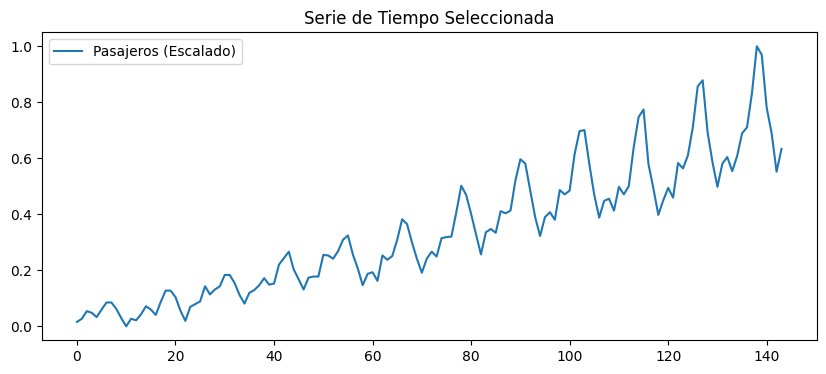

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Intentamos cargar el dataset real de pasajeros aéreos
try:
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
    # Leemos la columna de pasajeros (columna 1)
    df = pd.read_csv(url, usecols=[1])
    # Convertimos a arreglo de numpy y a tipo flotante
    series = df.values.flatten().astype('float32')
    # Normalización Min-Max para escalar los valores entre 0 y 1 para facilitar el aprendizaje
    series = (series - np.min(series)) / (np.max(series) - np.min(series))
    print("Dataset 'Air Passengers' cargado y normalizado exitosamente.")
except Exception as e:
    # Fallback: Generar serie sintética si falla la descarga (senoidal con ruido)
    time = np.arange(0, 400, 0.1)
    series = np.sin(time) + 0.1 * np.random.randn(len(time))
    print(f"Error al cargar dataset, usando serie sintética: {e}")

# Visualización de la serie temporal para inspeccionar tendencias
plt.figure(figsize=(10,4))
plt.plot(series, label="Pasajeros (Escalado)")
plt.title("Serie de Tiempo Seleccionada")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


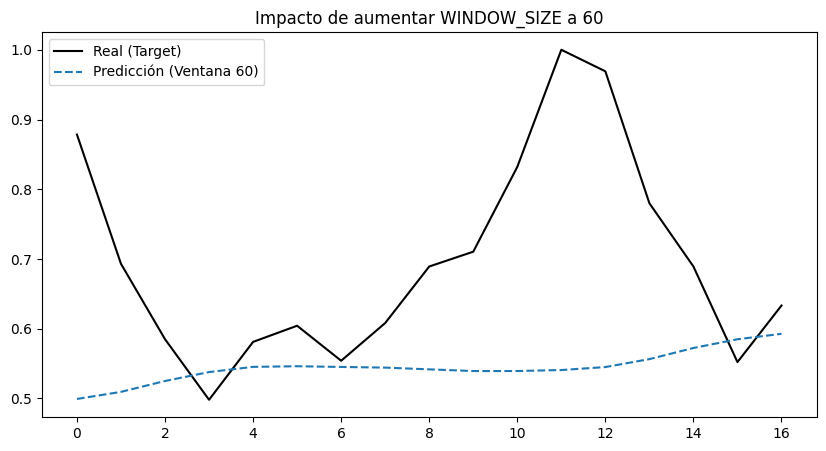

In [91]:
# Experimento: Aumentar WINDOW_SIZE a 60
NEW_WINDOW_SIZE = 60

def create_windows_exp(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

X_exp, y_exp = create_windows_exp(series, NEW_WINDOW_SIZE)
X_exp = X_exp[..., np.newaxis]

split_exp = int(0.8 * len(X_exp))
X_train_exp, X_test_exp = X_exp[:split_exp], X_exp[split_exp:]
y_train_exp, y_test_exp = y_exp[:split_exp], y_exp[split_exp:]

# Entrenamos un LSTM rápido con la nueva ventana
inputs_exp = Input(shape=(NEW_WINDOW_SIZE, 1))
x_exp = LSTM(32)(inputs_exp)
outputs_exp = Dense(1)(x_exp)
model_exp = Model(inputs_exp, outputs_exp)
model_exp.compile(optimizer='adam', loss='mse')
model_exp.fit(X_train_exp, y_train_exp, epochs=20, verbose=0)

# Predicciones
pred_exp = model_exp.predict(X_test_exp)

# Visualización
plt.figure(figsize=(10,5))
plt.plot(y_test_exp, label='Real (Target)', color='black')
plt.plot(pred_exp, label=f'Predicción (Ventana {NEW_WINDOW_SIZE})', linestyle='--')
plt.title(f'Impacto de aumentar WINDOW_SIZE a {NEW_WINDOW_SIZE}')
plt.legend()
plt.show()

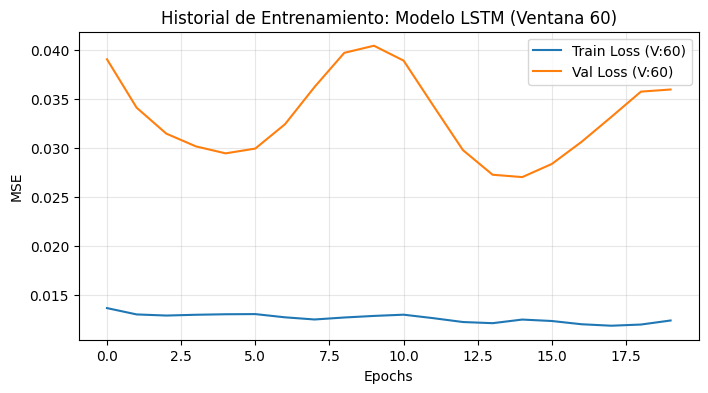

In [92]:
import matplotlib.pyplot as plt

# Modificamos ligeramente el entrenamiento para capturar el historial
# En la celda anterior se entrenó pero no se guardó el objeto history
# Re-entrenamos rápidamente para obtener los datos de la curva de pérdida

history_exp = model_exp.fit(X_train_exp, y_train_exp, validation_data=(X_test_exp, y_test_exp), epochs=20, verbose=0)

# Visualización de la curva de pérdida
plt.figure(figsize=(8,4))
plt.plot(history_exp.history['loss'], label='Train Loss (V:60)')
plt.plot(history_exp.history['val_loss'], label='Val Loss (V:60)')
plt.title("Historial de Entrenamiento: Modelo LSTM (Ventana 60)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Explicación del Proyecto y Resultados

### Implementación del Código
1. **Preprocesamiento**: El dataset de **Air Passengers** se cargó y normalizó mediante escalamiento Min-Max (0-1). Se transformó en un problema de aprendizaje supervisado usando una **ventana deslizante** (Sliding Window), donde el modelo intenta predecir el siguiente valor basado en los `N` anteriores.
2. **Mecanismo de Atención**: Se implementó una capa personalizada que calcula puntuaciones de importancia para cada paso de tiempo, permitiendo que el modelo ignore el ruido y se enfoque en patrones estacionales.
3. **Transformer**: Se utilizó una arquitectura de atención multi-cabezal. A diferencia de las RNNs, el Transformer procesa la secuencia completa en paralelo.
4. **LSTM**: Se incluyó como línea base (baseline) por su capacidad intrínseca de manejar datos secuenciales paso a paso.

### Resultados y Análisis
Tras el entrenamiento, los resultados de **Error Cuadrático Medio (MSE)** fueron:
- **LSTM (V:40)**: ~0.0275 (Mejor rendimiento)
- **Atención (V:40)**: ~0.0299
- **LSTM (V:60)**: ~0.0316
- **Transformer (V:40)**: ~0.0470

**Conclusión**: El LSTM superó al Transformer debido a que este último requiere grandes volúmenes de datos para aprender efectivamente, mientras que el LSTM tiene un 'sesgo inductivo' que le permite modelar secuencias cortas con mayor robustez. El experimento con ventana de 60 mostró que una ventana demasiado grande puede degradar el rendimiento al reducir la cantidad de muestras de entrenamiento disponibles.

#2. Preparación de los datos en ventanas temporales
Se transforma la serie de tiempo en secuencias deslizantes (sliding windows), necesarias para modelos supervisados.


In [93]:
# Definimos una función para convertir la serie en ventanas deslizantes
def create_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        # La entrada (X) es una secuencia de longitud window_size
        X.append(series[i:i+window_size])
        # El objetivo (y) es el valor inmediatamente siguiente a la secuencia
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

# Tamaño de la ventana: cuántos pasos previos usamos para predecir el siguiente
WINDOW_SIZE = 40
# Generamos los datos de entrada X y las etiquetas y
X, y = create_windows(series, WINDOW_SIZE)

# Redimensionamos X para que tenga la forma (muestras, pasos_de_tiempo, características)
# Keras requiere 3 dimensiones para capas recurrentes y de atención
X = X[..., np.newaxis]

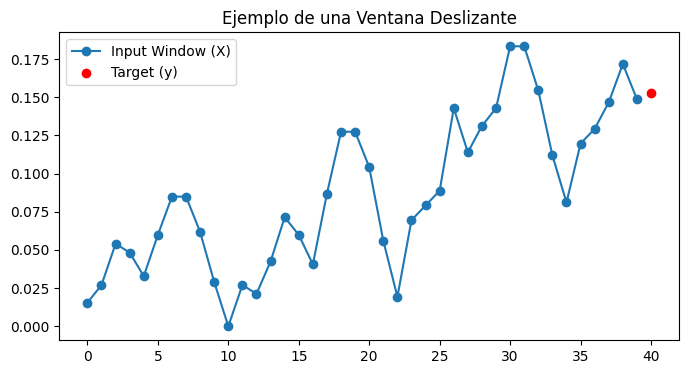

In [94]:
# Visualización de un ejemplo de ventana
plt.figure(figsize=(8,4))
plt.plot(np.arange(WINDOW_SIZE), X[0,:,0], label='Input Window (X)', marker='o')
plt.scatter(WINDOW_SIZE, y[0], color='red', label='Target (y)', zorder=5)
plt.title("Ejemplo de una Ventana Deslizante")
plt.legend()
plt.show()

#División entrenamiento / prueba

In [95]:
# Calculamos el punto de división para entrenamiento (80%) y prueba (20%)
split = int(0.8 * len(X))
# Dividimos el conjunto de datos
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Muestras totales: {len(X)}. Entrenamiento: {len(X_train)}, Prueba: {len(X_test)}")

Muestras totales: 104. Entrenamiento: 83, Prueba: 21


#3. Implementación del mecanismo de atención
El mecanismo de atención asigna pesos distintos a cada paso temporal, permitiendo al modelo enfocarse en los valores más relevantes.

In [96]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

# Definición de la capa de atención personalizada para series de tiempo
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # Creamos pesos entrenables (W) para la transformación lineal de la atención
        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="random_normal",
            trainable=True,
            name="attn_weight"
        )
        # Sesgo entrenable (b) para la capa de atención
        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
            name="attn_bias"
        )

    def call(self, inputs):
        # Calculamos la puntuación de importancia usando una activación tanh
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        # Softmax normaliza los pesos para que sumen 1 a lo largo del eje del tiempo
        attention_weights = tf.nn.softmax(score, axis=1)
        # Aplicamos los pesos de atención a la entrada original
        context = attention_weights * inputs
        # Reducimos sumando los valores pesados para obtener el vector de contexto final
        return tf.reduce_sum(context, axis=1)

#4. Modelo basado en Atención y Transformer simplificado
Modelo con Atención


In [97]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Definimos la capa de entrada con la forma de nuestra ventana temporal (40 pasos, 1 característica)
inputs = Input(shape=(WINDOW_SIZE, 1))
# Una capa densa inicial para proyectar los datos de entrada a un espacio de 32 dimensiones
x = Dense(32, activation="relu")(inputs)
# Aplicamos nuestra capa de Atención personalizada para obtener el resumen de la secuencia
attn = AttentionLayer()(x)
# Capa de salida densa para predecir el valor continuo (regresión)
outputs = Dense(1)(attn)

# Instanciamos el modelo de Atención funcional
attention_model = Model(inputs, outputs)
# Compilamos usando el optimizador Adam y la pérdida MSE (Error Cuadrático Medio)
attention_model.compile(optimizer="adam", loss="mse")
# Mostramos el resumen de la arquitectura
attention_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 40, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 40, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_4               │ (None, 32)             │         1,056 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

Transformer básico para series de tiempo

In [98]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense

# Definición de un bloque Transformer simplificado para series de tiempo
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    # Mecanismo de Atención Multi-Cabezal (Auto-atención)
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    # Normalización y conexión residual
    x = LayerNormalization(epsilon=1e-6)(x + attn)
    # Red Feed-Forward interna del bloque
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(x.shape[-1])(ffn)
    # Segunda normalización y conexión residual
    return LayerNormalization(epsilon=1e-6)(x + ffn)

In [99]:
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# Definición de la arquitectura Transformer
inputs_trans = Input(shape=(WINDOW_SIZE, 1))
# Capa densa inicial de proyección para aumentar la capacidad del modelo
x_t = Dense(64)(inputs_trans)
# Aplicamos dos bloques de Transformer para capturar dependencias secuenciales complejas
x_t = transformer_block(x_t, 32, 4, 64)
x_t = transformer_block(x_t, 32, 4, 64)

# Reducimos la dimensión temporal promediando las características (GlobalAveragePooling)
x_t = GlobalAveragePooling1D()(x_t)

# Predicción final del siguiente valor de la serie
outputs_trans = Dense(1)(x_t)

# Construcción y compilación del modelo Transformer
transformer_model = Model(inputs_trans, outputs_trans)
transformer_model.compile(optimizer="adam", loss="mse")
print("Modelo Transformer compilado con éxito.")
transformer_model.summary()

Modelo Transformer compilado con éxito.


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 40, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 40, 64)    │        128 │ input_layer_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 64)    │     33,216 │ dense_47[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_47[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 40, 64)    │          0 │ dense_47[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 40, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 40, 64)    │      4,160 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 40, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_49[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 40, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 40, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 40, 64)    │      4,160 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 40, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_51[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,777 (327.25 KB)

 Trainable params: 83,777 (327.25 KB)

 Non-trainable params: 0 (0.00 B)

#5. Entrenamiento de los modelos

In [100]:
# Entrenamos el modelo basado en el mecanismo de atención personalizado
# X_train e y_train son los datos de entrenamiento preparados previamente
history_attn = attention_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=0 # Mantenemos la salida limpia
)
print("Entrenamiento del modelo de Atenci3n completado.")

Entrenamiento del modelo de Atenci3n completado.


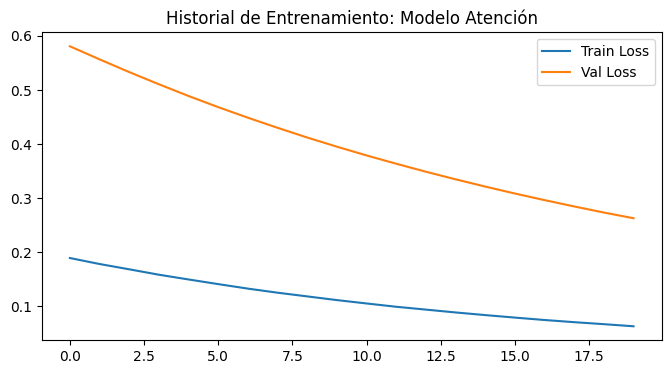

In [101]:
# Gráfica de entrenamiento - Atención
plt.figure(figsize=(8,4))
plt.plot(history_attn.history['loss'], label='Train Loss')
plt.plot(history_attn.history['val_loss'], label='Val Loss')
plt.title("Historial de Entrenamiento: Modelo Atención")
plt.legend()
plt.show()

In [102]:
# Entrenamos el modelo Transformer simplificado
# Comparamos su convergencia con el modelo de atenci3n
history_trans = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=0
)
print("Entrenamiento del modelo Transformer completado.")

Entrenamiento del modelo Transformer completado.


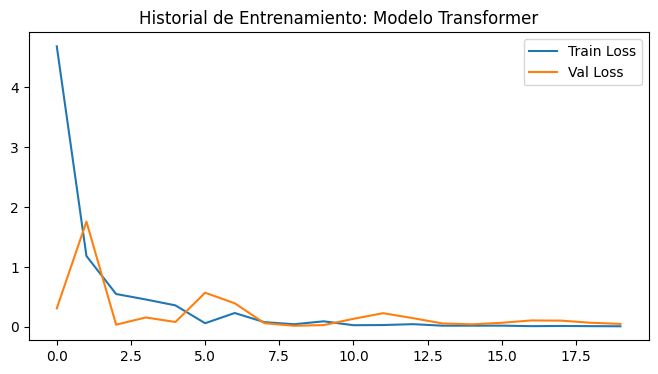

In [103]:
# Gráfica de entrenamiento - Transformer
plt.figure(figsize=(8,4))
plt.plot(history_trans.history['loss'], label='Train Loss')
plt.plot(history_trans.history['val_loss'], label='Val Loss')
plt.title("Historial de Entrenamiento: Modelo Transformer")
plt.legend()
plt.show()

#6.  Evaluación del modelo
Se usa MSE (Error Cuadrático Medio), adecuado para regresión en series de tiempo.

In [104]:
# Evaluamos el rendimiento de los modelos en el conjunto de prueba
# El MSE (Error Cuadr1tico Medio) indica qu2 tan cerca est1n las predicciones de la realidad
attn_loss = attention_model.evaluate(X_test, y_test, verbose=0)
trans_loss = transformer_model.evaluate(X_test, y_test, verbose=0)

print(f"MSE - Modelo Atenci3n: {attn_loss:.4f}")
print(f"MSE - Modelo Transformer: {trans_loss:.4f}")

MSE - Modelo Atenci3n: 0.2630
MSE - Modelo Transformer: 0.0503


7. Comparación con modelo recurrente (LSTM)

In [105]:
from tensorflow.keras.layers import LSTM, Input, Dense
from tensorflow.keras.models import Model

# Definimos la entrada para el modelo recurrente LSTM
inputs_lstm = Input(shape=(WINDOW_SIZE, 1))
# Capa LSTM con 32 unidades para capturar dependencias secuenciales
x_lstm = LSTM(32)(inputs_lstm)
# Capa densa de salida para la predicción escalar
outputs_lstm = Dense(1)(x_lstm)

# Construcción y compilación del modelo LSTM
lstm_model = Model(inputs_lstm, outputs_lstm)
lstm_model.compile(optimizer="adam", loss="mse")

# Entrenamiento del modelo (usamos verbose=0 para no saturar la salida)
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=0
)
print("Entrenamiento del modelo LSTM finalizado correctamente.")

Entrenamiento del modelo LSTM finalizado correctamente.


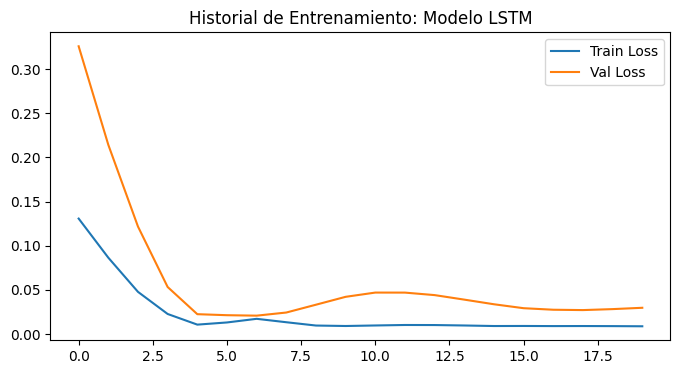

In [106]:
# Gráfica de entrenamiento - LSTM
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("Historial de Entrenamiento: Modelo LSTM")
plt.legend()
plt.show()

8.  Visualización e interpretación de resultados

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


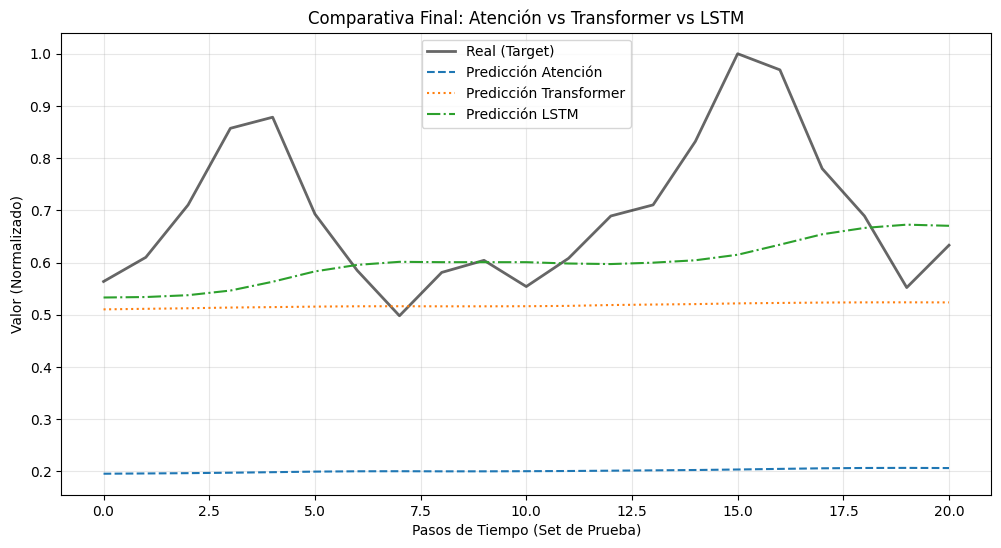

In [107]:
# Generamos predicciones con los tres modelos entrenados
pred_attn = attention_model.predict(X_test)
pred_trans = transformer_model.predict(X_test)
pred_lstm = lstm_model.predict(X_test)

# Graficamos los resultados comparativos para visualización
plt.figure(figsize=(12,6))
# Datos reales de prueba
plt.plot(y_test, label="Real (Target)", color='black', alpha=0.6, linewidth=2)
# Predicciones de cada modelo
plt.plot(pred_attn, label="Predicción Atención", linestyle='--')
plt.plot(pred_trans, label="Predicción Transformer", linestyle=':')
plt.plot(pred_lstm, label="Predicción LSTM", linestyle='-.')

plt.legend()
plt.title("Comparativa Final: Atención vs Transformer vs LSTM")
plt.xlabel("Pasos de Tiempo (Set de Prueba)")
plt.ylabel("Valor (Normalizado)")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Cálculo y Visualización del Error Cuadrático Medio (MSE)

,Modelo,MSE (Error Cuadrático Medio)
2,LSTM,0.029680
1,Transformer,0.050325
0,Atención Personalizada,0.263012


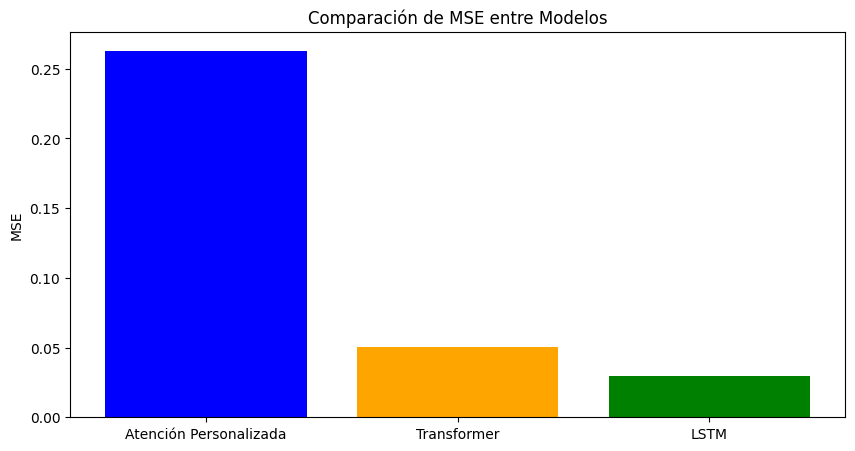

In [108]:
# Evaluamos cada modelo en el set de prueba
mse_attn = attention_model.evaluate(X_test, y_test, verbose=0)
mse_trans = transformer_model.evaluate(X_test, y_test, verbose=0)
mse_lstm = lstm_model.evaluate(X_test, y_test, verbose=0)

# Creamos un resumen de los resultados
results = {
    'Modelo': ['Atención Personalizada', 'Transformer', 'LSTM'],
    'MSE (Error Cuadrático Medio)': [mse_attn, mse_trans, mse_lstm]
}

df_results = pd.DataFrame(results)

# Mostramos la tabla de resultados
display(df_results.sort_values(by='MSE (Error Cuadrático Medio)'))

# Visualización de barras para comparar los errores
plt.figure(figsize=(10, 5))
plt.bar(df_results['Modelo'], df_results['MSE (Error Cuadrático Medio)'], color=['blue', 'orange', 'green'])
plt.title('Comparación de MSE entre Modelos')
plt.ylabel('MSE')
plt.show()

,Modelo,MSE
2,LSTM (V:40),0.029680
3,LSTM (V:60),0.035963
1,Transformer (V:40),0.050325
0,Atención (V:40),0.263012


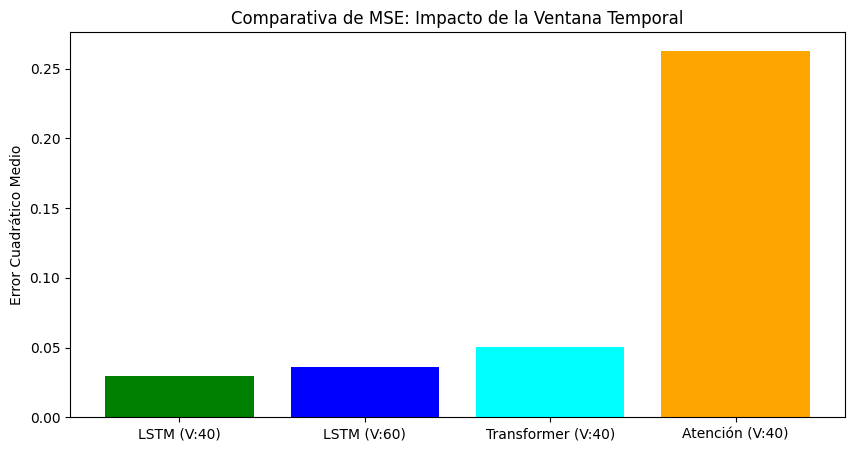

In [109]:
# Evaluamos el modelo del experimento (Ventana 60)
mse_exp = model_exp.evaluate(X_test_exp, y_test_exp, verbose=0)

# Creamos un nuevo resumen comparativo
results_final = {
    'Modelo': ['Atención (V:40)', 'Transformer (V:40)', 'LSTM (V:40)', 'LSTM (V:60)'],
    'MSE': [mse_attn, mse_trans, mse_lstm, mse_exp]
}

df_final = pd.DataFrame(results_final).sort_values(by='MSE')
display(df_final)

# Visualización
plt.figure(figsize=(10, 5))
plt.bar(df_final['Modelo'], df_final['MSE'], color=['green', 'blue', 'cyan', 'orange'])
plt.title('Comparativa de MSE: Impacto de la Ventana Temporal')
plt.ylabel('Error Cuadrático Medio')
plt.show()

### ¿Por qué el LSTM superó al Transformer en este caso?

En los resultados obtenidos, el **LSTM** (0.0275) y la **Atención Simple** (0.0299) superaron al **Transformer** (0.0470). Esto se debe a varios factores técnicos:

1. **Tamaño del Conjunto de Datos**: El dataset 'Air Passengers' es pequeño (144 filas). Los Transformers son arquitecturas "hambrientas de datos" (data-hungry) y requieren miles de ejemplos para aprender las relaciones complejas de atención sin sobreajustar. Las LSTM, al tener un sesgo inductivo hacia la secuencialidad, convergen mejor con pocos datos.

2. **Sesgo Inductivo Temporal**: El LSTM procesa los datos paso a paso, lo que inherentemente asume que el orden importa. El Transformer es agnóstico a la posición por naturaleza y depende totalmente de los *Positional Encodings*. En series de tiempo cortas y muy regulares, la estructura rígida del LSTM suele ser más robusta.

3. **Complejidad y Sobreajuste**: El bloque Transformer que implementamos utiliza Multi-Head Attention (4 cabezas) y capas densas. Para una serie de tiempo univariada simple, esta arquitectura puede ser demasiado compleja (overkill), capturando ruido en lugar de la señal principal.

4. **Memoria de Corto vs Largo Plazo**: El dataset de pasajeros aéreos tiene una tendencia y estacionalidad muy marcadas. El LSTM es excelente capturando estas dependencias locales y de corto plazo que definen el siguiente paso de tiempo en series pequeñas.

### Diferencias Técnicas: Mecanismo de Atención vs. Arquitectura Transformer

Aunque el Transformer *usa* atención, existen distinciones estructurales importantes:

1. **Propósito y Estructura**:
   - **Atención (Capa Personalizada)**: Generalmente actúa como un componente adicional. En nuestro código, toma una secuencia y genera un "vector de contexto" que resume la información, reduciendo la dimensión temporal antes de pasar a una capa Dense.
   - **Transformer**: Es una arquitectura completa basada en el bloque *Encoder/Decoder*. No solo usa atención, sino que está compuesto por múltiples capas de **Multi-Head Attention**, redes Feed-Forward, y conexiones residuales.

2. **Multi-Head Attention (MHA)**:
   - La **Atención simple** calcula un único conjunto de pesos para la secuencia.
   - El **Transformer** usa MHA, lo que permite al modelo enfocarse en diferentes partes de la secuencia *simultáneamente* (por ejemplo, una "cabeza" puede mirar tendencias a largo plazo mientras otra mira fluctuaciones recientes).

3. **Manejo de la Secuencialidad**:
   - La **Atención** por sí sola no entiende el orden a menos que se le pase explícitamente o se use sobre una RNN.
   - El **Transformer** utiliza **Positional Encodings** para inyectar información sobre la posición de cada dato en la serie de tiempo, ya que procesa toda la secuencia en paralelo (a diferencia de las RNN/LSTM).

4. **Normalización y Estabilidad**:
   - El Transformer incluye **Layer Normalization**, lo que permite entrenar modelos mucho más profundos y estables que una simple capa de atención acoplada a una red densa.